# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [17]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

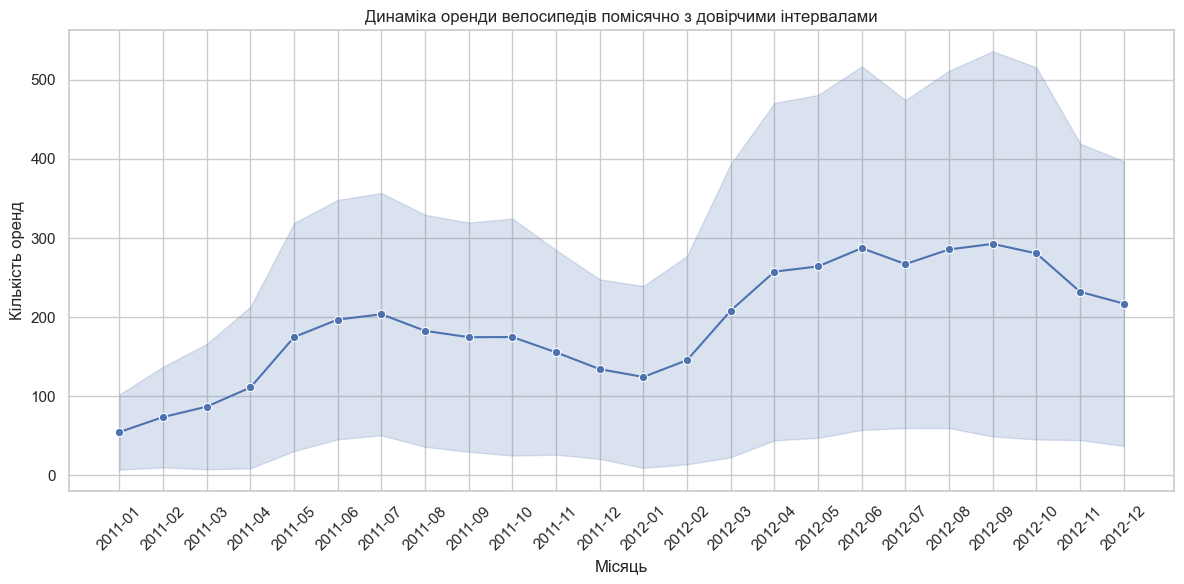

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    errorbar='sd',
    marker='o'
)

plt.title('Динаміка оренди велосипедів помісячно з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Найбільша невизначеність виникає з 5 по 9 місяці, бо дивлячись на графік ми помічаємо, що їх діапазон відхилення ширший.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

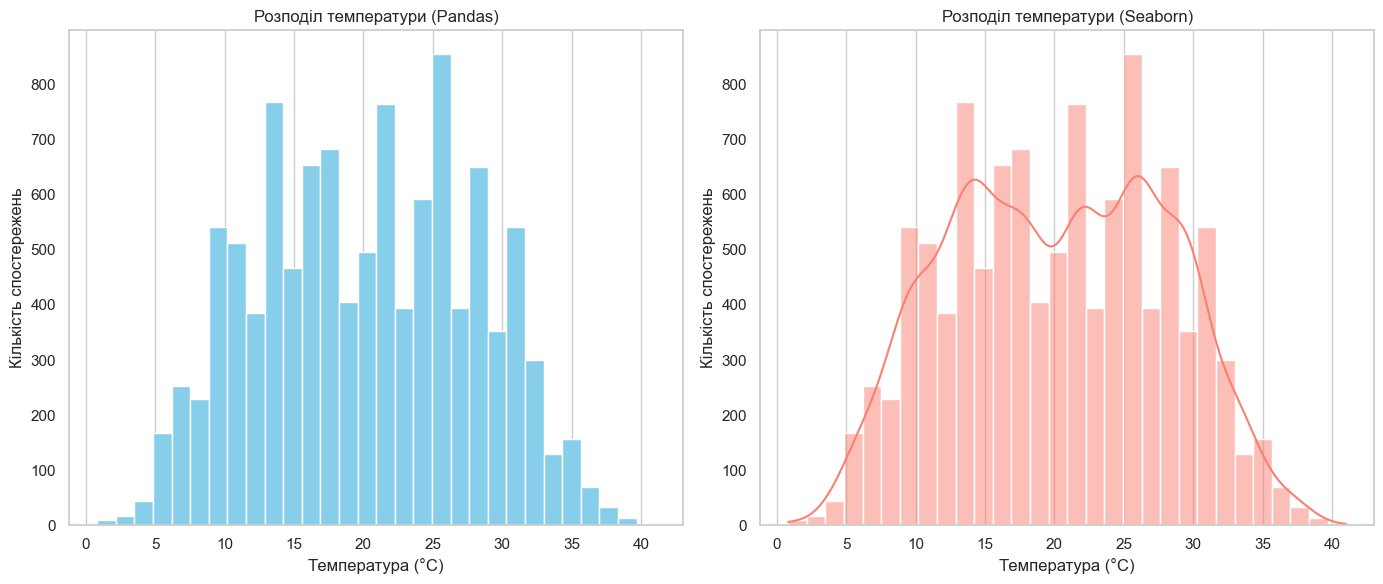

In [49]:
plt.figure(figsize=(14, 6))

# створюємо першу з двох панелей і встановлюємо поточну вісь
plt.subplot(1, 2, 1)  # (рядки, колонки, номер панелі)
plt.hist(df['temp'], bins=30, color='skyblue')
plt.title('Розподіл температури (Pandas)')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість спостережень')
plt.grid(axis='y')

# створюємо другу з двох панелей і встановлюємо поточну вісь
plt.subplot(1, 2, 2)
sns.histplot(df, x="temp", bins=30, color='salmon', kde=True)
plt.title('Розподіл температури (Seaborn)')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість спостережень')
plt.grid(axis='y')

plt.tight_layout()
plt.show();

1. По суті у даному випадку різниці не бачу, лище крива лінія на графіку в Seaborn, яку ми зазначили додатково в коді.
2. Це крива згладжена лінія, шо показує загальну форму розподілу більш зрозуміло: піки, симетричність.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

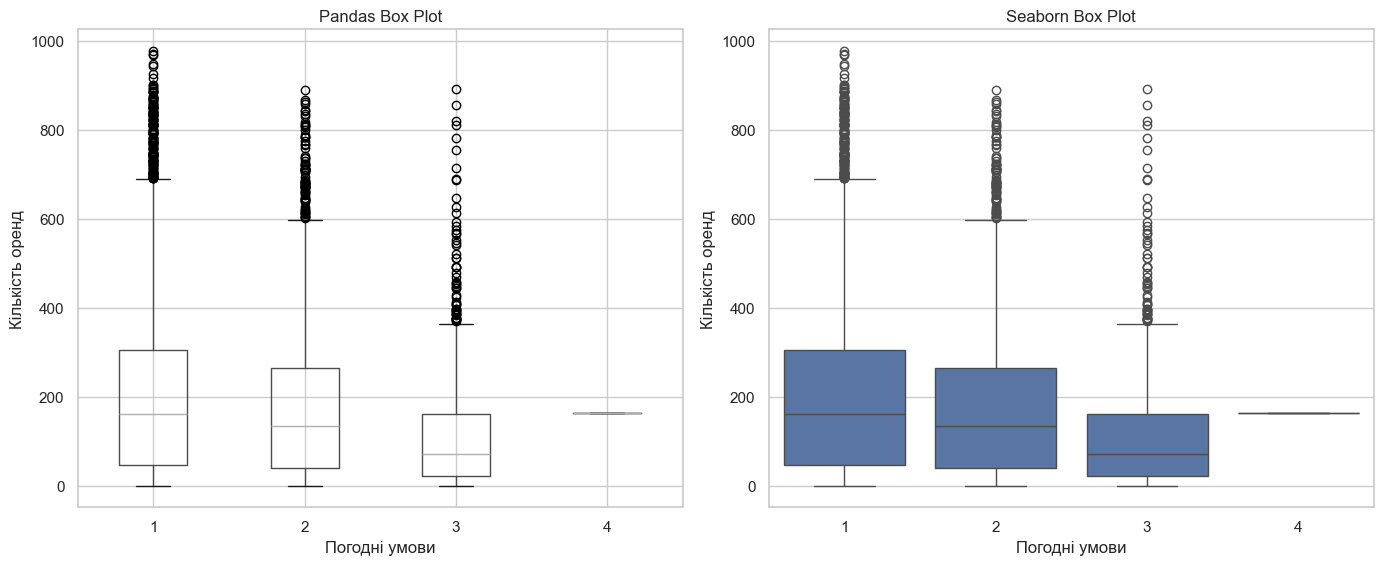

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

# Pandas Box Plot
df.boxplot(column='count', by='weather', ax=axes[0])
axes[0].set_title('Pandas Box Plot')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')
fig.suptitle('') 

# Seaborn Box Plot
sns.boxplot(data=df, x='weather', y='count', ax=axes[1])
axes[1].set_title('Seaborn Box Plot')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()


Візуальна різниця між Pandas та Seaborn тут прослідковується більше. Базові налаштування кольорів відрізняються. Ширина boxes виглядає не однаково.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


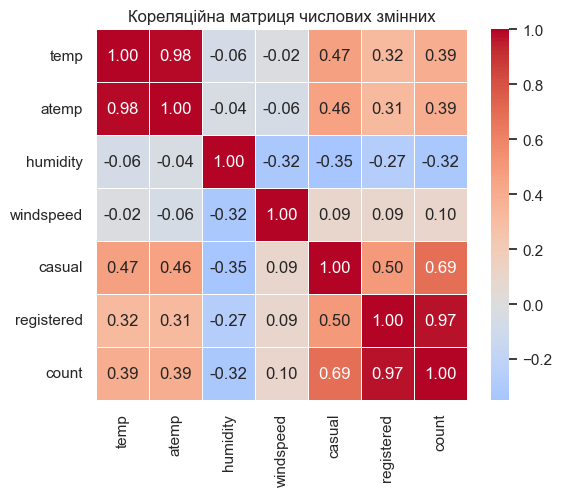

In [91]:
# Обчислюємо кореляційну матрицю
correlation = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

# Створюємо heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    correlation,       # матриця кореляцій
    annot=True,        # підписуємо значення в клітинках
    fmt=".2f",         # два знаки після коми
    cmap='coolwarm',   # колірна палітра
    center=0,          # центр палітри на 0
    square=True,       # квадратні клітинки
    linewidths=0.5     # товщина ліній між клітинками
)

plt.title('Кореляційна матриця числових змінних')
plt.tight_layout()
plt.show()


In [ ]:
1. Temp, atemp, humidity, windspeed
2. 0.98 Відхилення маленьке, тому що ці показники майже однакові, відтворюють майже одне й те ж саме.
3. Humidity - адже це вологість (дощ, відчувається не комфортно на дворі), чим вона вища тим менше бажаючих користуватися велосипедом.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


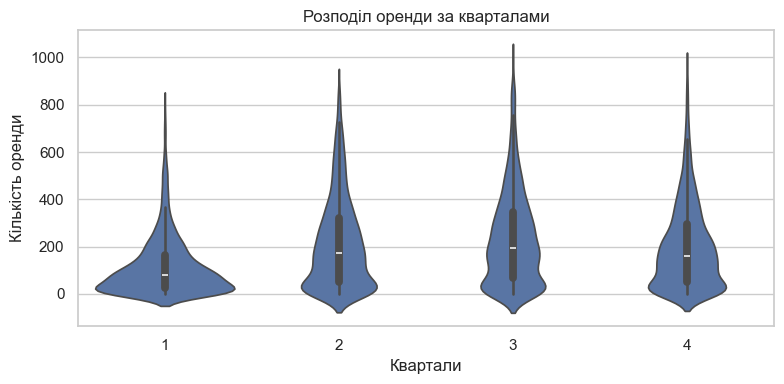

In [95]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='season', y='count')
plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартали')
plt.ylabel('Кількість оренди')
plt.tight_layout()
plt.show()

1. "Товщина" violin plot в нашому випадку показує найчастішу кількість оендованих велосипедів.
2. Найбільша варіабельність оренди у 3-му кварталі.
3. Перевага violin plot над звичайним box plot, у тому що вона показує форму розподілу.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

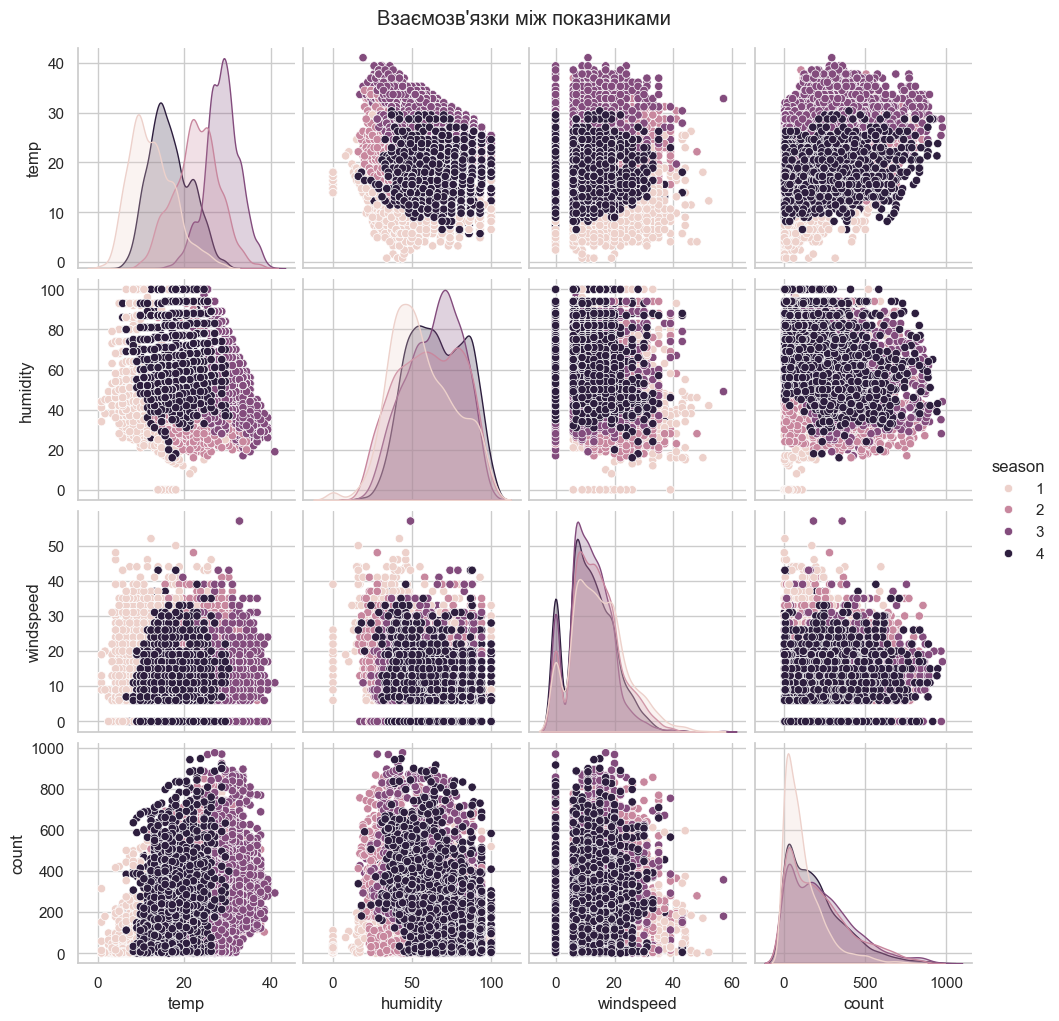

In [105]:
sns.pairplot(df[['temp', 'humidity', 'windspeed', 'count', 'season']], hue='season')
plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.show()

1. Між count та temp
2. temp

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

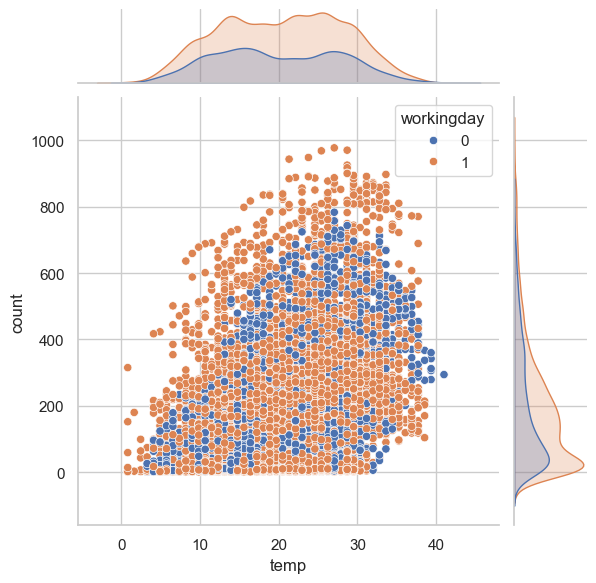

In [106]:
sns.jointplot(data=df, x='temp', y='count', hue='workingday');

1. По осі Х - розподіл температури, по осі У - кількость оренд.
2. У робочі дні кількість оренд трішки більша.